In [1]:
import os
import gc
import time
import argparse
import datetime
from typing import List, Dict
import numpy as np
import pandas as pd
import torch
from omegaconf import OmegaConf
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import transforms
from segment_anything import SamPredictor, sam_model_registry

import sys

from sam_engine import Engine, override_args, get_default_datasets
from processors import get_encoder_processor, DecoderDoNothingProcessor
from train.utils.dataloader import get_im_gt_name_dict, Resize
from data_utils import OnlineDataset
import train.utils.misc as misc
from train.train import compute_iou, compute_boundary_iou
from types import SimpleNamespace
from prunning_rate.sampruneduo import image_encoder_monkey_patch_train_duo
os.environ["CUDA_VISIBLE_DEVICES"] = "3"


/home/ubuntu/miniconda3/envs/quantsam/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ubuntu/miniconda3/envs/quantsam/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/ubuntu/miniconda3/envs/quantsam/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/ubuntu/21chi.nh/Quantization/SAM_Quantization/SAM_Quantization/sam-hq/segment_anything/modeling/tiny_vit_sam.py:662: UserWar

In [2]:
model_type = "vit_l"
checkpoint_path = "./pretrained_checkpoint/sam_hq_vit_l.pth"

sam = sam_model_registry[model_type](checkpoint=checkpoint_path).to('cuda')
predictor = SamPredictor(sam)

# Initialize engine
engine = Engine(
    'batch_benchmark',
    quantize_encoder=True,
    quantize_decoder=False
)

# Get processor
enc_processor = get_encoder_processor("ENTROPY_VALUE_CHECK")

args = SimpleNamespace(
    threshold=0.5,
    percent=0.5,
    percent_global=0.5,
    high_entropy=True,          # IMPORTANT: match the attribute name your code uses
    prune_global=True,
    model_type=model_type,
    global_percent=0.5,
)

encoder_processor, decoder_processor = engine.setup_and_calibrate_processors(
    predictor,
    num_calib_samples=16,
    encoder_processor=enc_processor,
    decoder_processor=DecoderDoNothingProcessor("DO_NOTHING"),
    args_yaml=args,
)



/home/ubuntu/21chi.nh/Quantization/SAM_Quantization/SAM_Quantization/sam-hq/segment_anything/build_sam.py:162: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = tor

<All keys matched successfully>
------------------------------ valid --------------------------------
--->>> valid  dataset  0 / 1   DIS5K-TR <<<---
-im- DIS5K-TR ./data/DIS5K/DIS-TR/im :  3000
-gt- DIS5K-TR ./data/DIS5K/DIS-TR/gt :  3000
------------------------------ valid --------------------------------
--->>> valid  dataset  0 / 1   DIS5K-VD <<<---
-im- DIS5K-VD ./data/DIS5K/DIS-VD/im :  470
-gt- DIS5K-VD ./data/DIS5K/DIS-VD/gt :  470
------------------------------ valid --------------------------------
--->>> valid  dataset  0 / 1   DIS5K-VD <<<---
-im- DIS5K-VD ./data/DIS5K/DIS-VD/im :  470
-gt- DIS5K-VD ./data/DIS5K/DIS-VD/gt :  470
Setting up encoder processor...
Registering attention hook for blocks.0.attn
Registering attention hook for blocks.1.attn
Registering attention hook for blocks.2.attn
Registering attention hook for blocks.3.attn
Registering attention hook for blocks.4.attn
Registering attention hook for blocks.5.attn
Registering attention hook for blocks.6.attn
Regi

After sample 1: blocks.0.attn.head_0 has 1 entropy values


After sample 2: blocks.0.attn.head_0 has 2 entropy values


After sample 3: blocks.0.attn.head_0 has 3 entropy values


Calculating final entropy variance and mean from accumulated data...
Encoder processor calibrated on 16 samples


In [3]:
import re
import numpy as np
import torch
import matplotlib.pyplot as plt

def _to_numpy_1d(x):
    """Convert torch Tensor/Parameter/list/np array -> 1D numpy float array."""
    if isinstance(x, torch.nn.Parameter):
        x = x.data
    if torch.is_tensor(x):
        x = x.detach().cpu().float().flatten().numpy()
    elif isinstance(x, (list, tuple)):
        x = np.asarray(x, dtype=np.float64).reshape(-1)
    else:
        x = np.asarray(x, dtype=np.float64).reshape(-1)
    return x

def _extract_entropy_vector(entropy_list, num_heads=None):
    """
    entropy_list: [(head_idx, entropy), ...]
    Returns entropy_values aligned by head index: shape (H,)
    """
    # Determine head count
    if num_heads is None:
        num_heads = max(h for h, _ in entropy_list) + 1 if len(entropy_list) else 0
    ent = np.full((num_heads,), np.nan, dtype=np.float64)
    for h, v in entropy_list:
        if 0 <= int(h) < num_heads:
            ent[int(h)] = float(v)
    # If any NaNs remain (missing heads), drop them later via mask
    return ent


def clamp_to_0_1(w):
    """
    Hard clamp values to [0, 1] without changing values already in range.

    - w < 0 → 0
    - 0 ≤ w ≤ 1 → unchanged
    - w > 1 → 1
    """
    w = w.astype(np.float64)
    return np.clip(w, 0.0, 1.0)

def _pearsonr(x, y):
    """Pearson correlation without scipy."""
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    x = x - x.mean()
    y = y - y.mean()
    denom = np.sqrt((x * x).sum()) * np.sqrt((y * y).sum())
    return np.nan if denom == 0 else float((x * y).sum() / denom)

def _spearmanr(x, y):
    """Spearman correlation without scipy (rank + Pearson)."""
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    def rankdata(a):
        # average rank for ties
        order = np.argsort(a, kind="mergesort")
        ranks = np.empty_like(order, dtype=np.float64)
        ranks[order] = np.arange(1, len(a) + 1, dtype=np.float64)
        # tie handling
        sorted_a = a[order]
        i = 0
        while i < len(a):
            j = i
            while j + 1 < len(a) and sorted_a[j + 1] == sorted_a[i]:
                j += 1
            if j > i:
                avg = (ranks[order[i]] + ranks[order[j]]) / 2.0
                ranks[order[i:j+1]] = avg
            i = j + 1
        return ranks

    rx = rankdata(x)
    ry = rankdata(y)
    return _pearsonr(rx, ry)

def plot_and_correlate_entropy_vs_gates(
    entropy_value: dict,
    full_attention_heads: dict,
    *,
    clamp_weights_0_1: bool = False,
    per_layer_plots: bool = False,
    max_layers_to_plot: int = 12,
    title_prefix: str = ""
):
    """
    Measures correlation + plots entropy vs gate weight across heads.

    Inputs
    - entropy_value: dict[layer_name] = [(head_idx, entropy), ...]
    - full_attention_heads: dict[layer_name] = torch Parameter/Tensor/list of gate weights per head

    Options
    - clamp_weights_0_1: if True, normalize weights into [0,1] before plotting/correlation
   
    - per_layer_plots: if True, also plot each layer separately (up to max_layers_to_plot)
    """

    common_layers = sorted(set(entropy_value.keys()) & set(full_attention_heads.keys()))
    if not common_layers:
        raise ValueError("No overlapping layer keys between entropy_value and full_attention_heads.")

    # Collect global points
    all_ent = []
    all_w = []
    per_layer_stats = {}

    for layer in common_layers:
        w = _to_numpy_1d(full_attention_heads[layer])
        ent = _extract_entropy_vector(entropy_value[layer], num_heads=len(w))

        # align and drop missing heads (nan)
        mask = np.isfinite(ent) & np.isfinite(w)
        ent = ent[mask]
        w = w[mask]

        if clamp_weights_0_1:
            w = clamp_to_0_1(w)

        if len(ent) < 2:
            continue

        # store
        all_ent.append(ent)
        all_w.append(w)

        per_layer_stats[layer] = {
            "n_heads": int(len(ent)),
            "pearson_r": _pearsonr(ent, w),
            "spearman_r": _spearmanr(ent, w),
            "entropy_mean": float(np.mean(ent)),
            "weight_mean": float(np.mean(w)),
        }

    if not all_ent:
        raise ValueError("After alignment, no layer had enough valid head entries to analyze.")

    all_ent = np.concatenate(all_ent, axis=0)
    all_w = np.concatenate(all_w, axis=0)

    # Global correlations
    pearson_r = _pearsonr(all_ent, all_w)
    spearman_r = _spearmanr(all_ent, all_w)

    # ---- Global plot ----
    plt.figure(figsize=(7.5, 5.5))
    plt.scatter(all_ent, all_w, s=8, alpha=0.35)
    plt.xlabel("Entropy (per head)")
    main_title = f"{title_prefix}Entropy vs Gate Weight | Pearson r={pearson_r:.4f}, Spearman ρ={spearman_r:.4f}"
    plt.title(main_title.strip())
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    # ---- Optional per-layer plots ----
    if per_layer_plots:
        # plot a subset (sorted by layer index if present)
        def layer_sort_key(name):
            m = re.search(r"blocks\.(\d+)\.attn", name)
            return int(m.group(1)) if m else 10**9

        layers_to_plot = sorted(per_layer_stats.keys(), key=layer_sort_key)[:max_layers_to_plot]
        for layer in layers_to_plot:
            w = _to_numpy_1d(full_attention_heads[layer])
            ent = _extract_entropy_vector(entropy_value[layer], num_heads=len(w))
            mask = np.isfinite(ent) & np.isfinite(w)
            ent = ent[mask]
            w = w[mask]
            if clamp_weights_0_1:
                w = clamp_to_0_1(w)

            pr = per_layer_stats[layer]["pearson_r"]
            sr = per_layer_stats[layer]["spearman_r"]

            plt.figure(figsize=(7.0, 5.0))
            plt.scatter(ent, w, s=10, alpha=0.45)
            plt.xlabel("Entropy (per head)")
            plt.title(f"{layer} | Pearson r={pr:.4f}, Spearman ρ={sr:.4f}")
            plt.grid(True, alpha=0.25)
            plt.tight_layout()
            plt.show()

    # Print a compact summary
    print(f"Global: N={len(all_ent)} heads | Pearson r={pearson_r:.6f} | Spearman ρ={spearman_r:.6f}")
    # Top layers by absolute Pearson correlation (for quick inspection)
    top = sorted(per_layer_stats.items(), key=lambda kv: abs(kv[1]["pearson_r"]), reverse=True)[:10]
    print("\nTop layers by |Pearson r|:")
    for layer, st in top:
        print(f"- {layer}: n={st['n_heads']}, r={st['pearson_r']:.6f}, ρ={st['spearman_r']:.6f}")

    return {
        "global": {"n_heads": int(len(all_ent)), "pearson_r": pearson_r, "spearman_r": spearman_r},
        "per_layer": per_layer_stats,
    
    }
def plot_and_correlate_entropy_vs_gates_split(
    entropy_value: dict,
    full_attention_heads: dict,
    *,
    clamp_weights_0_1: bool = False,
    per_layer_plots: bool = False,
    max_layers_to_plot: int = 12,
    title_prefix: str = ""
):
    common_layers = sorted(set(entropy_value.keys()) & set(full_attention_heads.keys()))
    
    # Global containers for Grouped Analysis
    groups = {
        "Local": {"ent": [], "w": []},
        "Global": {"ent": [], "w": []}
    }
    per_layer_stats = {}

    for layer in common_layers:
        w_raw = _to_numpy_1d(full_attention_heads[layer])
        ent_raw = _extract_entropy_vector(entropy_value[layer], num_heads=len(w_raw))

        # Align and drop missing heads
        mask = np.isfinite(ent_raw) & np.isfinite(w_raw)
        ent = ent_raw[mask]
        w = w_raw[mask]

        if clamp_weights_0_1:
            w = clamp_to_0_1(w)

        if len(ent) < 2:
            continue

        # Determine Layer Type based on number of heads
        # Local: num_heads % 100 == 0 | Global: num_heads % 100 != 0
        layer_type = "Local" if len(w_raw) % 100 == 0 else "Global"
        
        # 1. Add to group for aggregate measurement
        groups[layer_type]["ent"].append(ent)
        groups[layer_type]["w"].append(w)

        # 2. Measure individual layer stats
        per_layer_stats[layer] = {
            "type": layer_type,
            "n_heads": int(len(ent)),
            "pearson_r": _pearsonr(ent, w),
            "spearman_r": _spearmanr(ent, w),
            "entropy_mean": float(np.mean(ent)),
            "weight_mean": float(np.mean(w)),
        }

    # Process and Plot Grouped Results
    group_results = {}
    for g_name, g_data in groups.items():
        if not g_data["ent"]:
            continue
            
        all_ent = np.concatenate(g_data["ent"])
        all_w = np.concatenate(g_data["w"])
        
        p_r = _pearsonr(all_ent, all_w)
        s_r = _spearmanr(all_ent, all_w)
        group_results[g_name] = {"pearson": p_r, "spearman": s_r, "n": len(all_ent)}

        # ---- Group Plot ----
        plt.figure(figsize=(8, 6))
        # No internal labels/legends inside the plot area
        plt.scatter(all_ent, all_w, s=8, alpha=0.3, color='#1f77b4' )
        
        plt.xlabel("Entropy (per head)", fontsize=11)
        plt.ylabel("Gate Weight", fontsize=11)
        
        # All "notions" and stats are placed only in the Title
        plt.title(f"{title_prefix}{g_name} Group | r={p_r:.4f}, ρ={s_r:.4f} (N={len(all_ent)})", 
                  fontsize=12, fontweight='bold')
        
        plt.grid(True, linestyle=':', alpha=0.4)
        plt.tight_layout()
        plt.show()

    # Summary Print for console
    print("\n--- Summary of Results ---")
    for g_name, res in group_results.items():
        print(f"Group {g_name}: N={res['n']}, Pearson r={res['pearson']:.6f}, Spearman ρ={res['spearman']:.6f}")
    
    return {
        "groups": group_results,
        "per_layer": per_layer_stats
    }
    

In [4]:
args_duo = SimpleNamespace(
    train_prune_rate=SimpleNamespace(
        batch_size_train=2,
        threshold=0.5,
        threshold_globle=0.2,
    ),
    model=SimpleNamespace(
        model_type=model_type,
    ),
    quantization=SimpleNamespace(
        positional_quant=False,
        use_percentage=True,
    )
)

image_encoder_monkey_patch_train_duo(
            predictor.model,
            processor=None,
            args_yaml= args_duo,
            train = False,
        )
# checkpoint_path = "./pretrained_checkpoint/prune_rate/duo_sam_hq_epoch_torchnograd_distill10_vit_l_reg-weight_0.5_lr0.05_lr_drop2.pth"
checkpoint_path = "./pretrained_checkpoint/prune_rate/duo_sam_hq_epoch_torchnograd_distill10_vit_l_reg-weight_0.5_lr0.01_lr_drop2.pth"
# checkpoint_path = "./pretrained_checkpoint/prune_rate/duo_sam_hq_epoch_torchnograd_distill_balance10_vit_l_reg-weight_0.5_lr0.01_lr_drop2.pth"
checkpoint = torch.load(checkpoint_path, map_location='cpu')

predictor.model.load_state_dict(checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint)



/home/ubuntu/21chi.nh/Drone/TestTrainEvcap/tmp/ipykernel_2090447/3635597249.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map

<All keys matched successfully>

In [5]:
def get_full_attention_heads(model):
    full_attention_heads = {}
    for name, module in model.named_modules():
        if not hasattr(module, "full_attention_heads"):
            continue
        full_attention_heads[name]=module.full_attention_heads
    # for layer in model.image_encoder.blocks:
    #     module = layer.attn
    #     if not hasattr(module, "full_attention_heads"):
    #         continue
    #     full_attention_heads.append(module.full_attention_heads)
    return full_attention_heads

In [6]:
entropy_value = encoder_processor.layer_heads
full_attention_heads =get_full_attention_heads(predictor.model)


In [7]:
print(full_attention_heads)

print(entropy_value)

{'image_encoder.blocks.0.attn': Parameter containing:
tensor([ 5.3435e-07, -7.5210e-08,  1.2594e-08,  6.8588e-07,  4.2839e-09,
         2.4582e-07,  6.5300e-09, -5.3737e-08,  9.3352e-01, -4.8953e-08,
         3.0691e-01, -8.7487e-08,  5.9710e-06, -8.5369e-08, -1.4019e-08,
        -1.4823e-08, -7.7132e-09, -2.2064e-09,  1.5231e-08,  9.6885e-09,
        -8.4926e-10,  1.1197e-07,  2.2227e-08,  2.1602e-08,  8.0225e-01,
         7.6113e-08,  8.1995e-02, -9.2744e-08,  2.1891e-01,  2.4562e-09,
         3.4289e-08,  3.7791e-10, -2.0558e-08,  5.7242e-08, -1.6753e-08,
         6.7194e-08, -1.2845e-09,  5.6088e-10, -2.1679e-08, -1.6734e-09,
         8.3894e-01,  1.4682e-08,  1.0120e-01, -1.3858e-08, -1.7829e-07,
        -3.3282e-09, -9.7410e-09,  1.1080e-08,  1.1045e-02, -3.8489e-09,
         1.9140e-08, -1.0340e-07, -1.4665e-09, -1.0444e-08,  2.7389e-08,
        -5.5444e-09,  6.4109e-01, -1.0622e-08,  1.3266e-02, -1.2881e-08,
         1.8867e-08,  2.5274e-09,  8.1401e-09,  2.3511e-08,  1.2358e-0

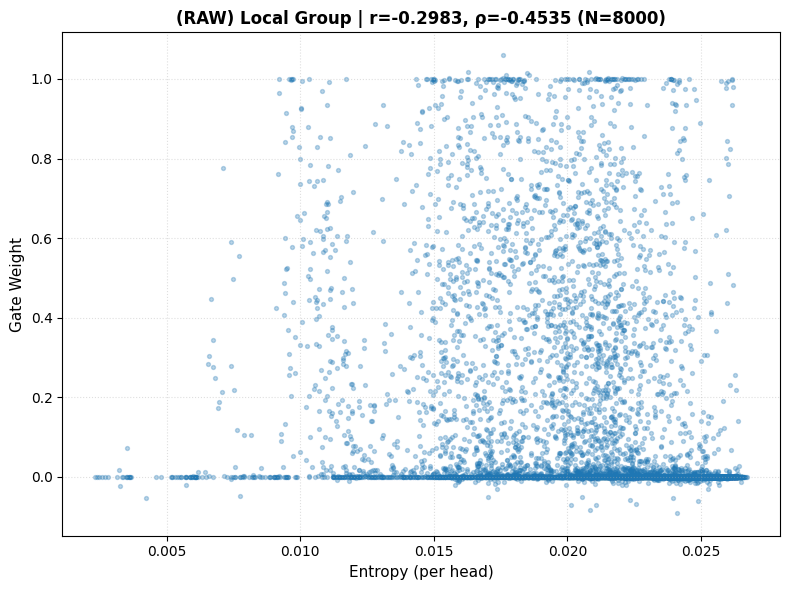

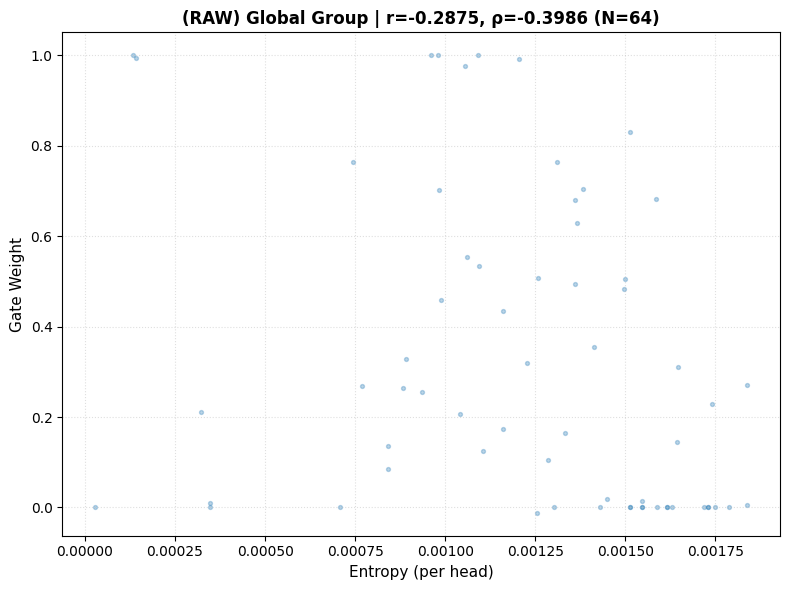


--- Summary of Results ---
Group Local: N=8000, Pearson r=-0.298295, Spearman ρ=-0.453513
Group Global: N=64, Pearson r=-0.287479, Spearman ρ=-0.398626


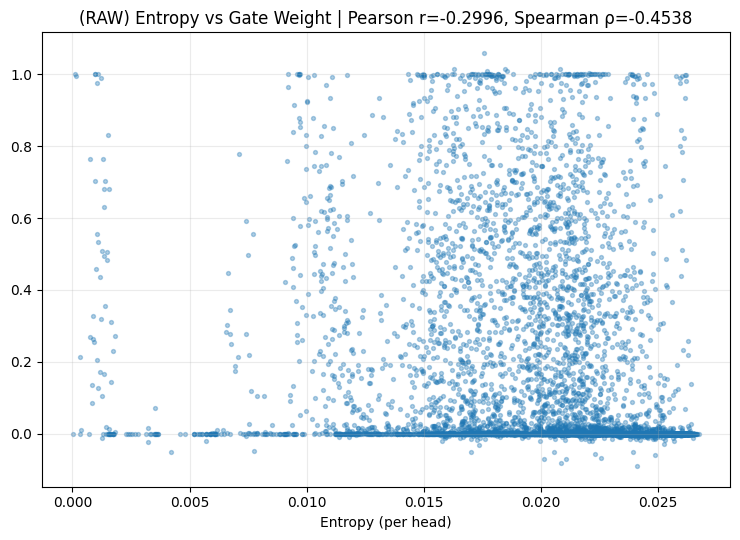

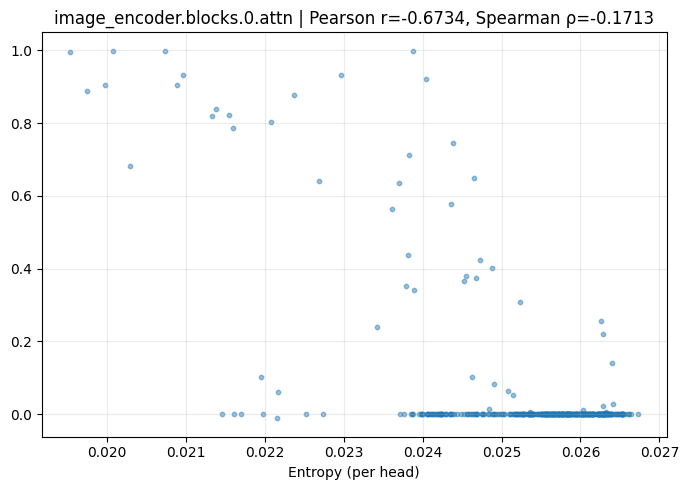

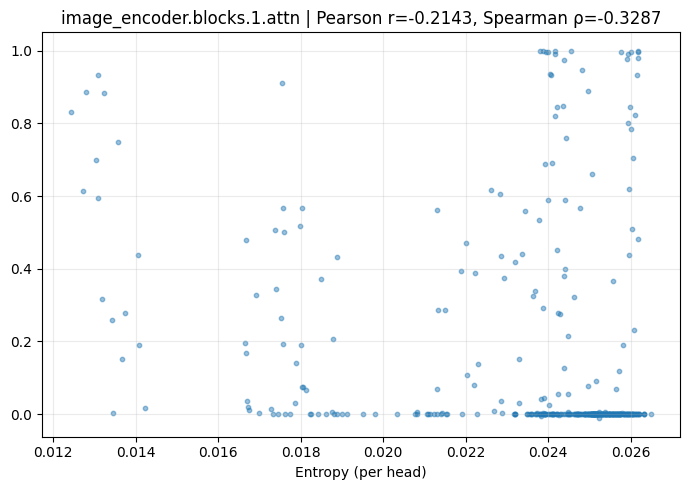

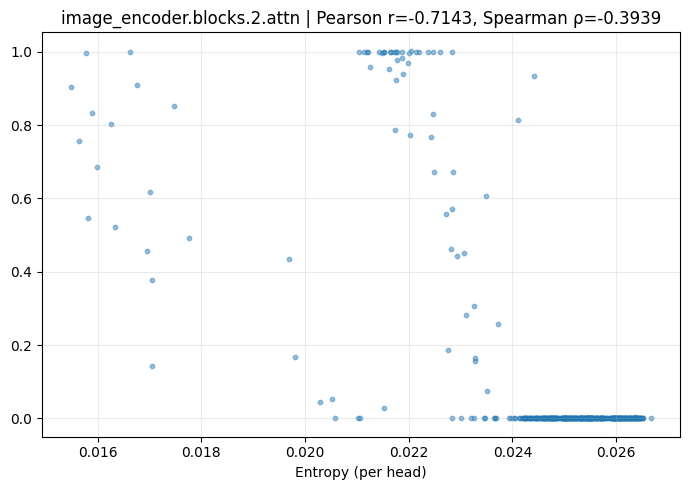

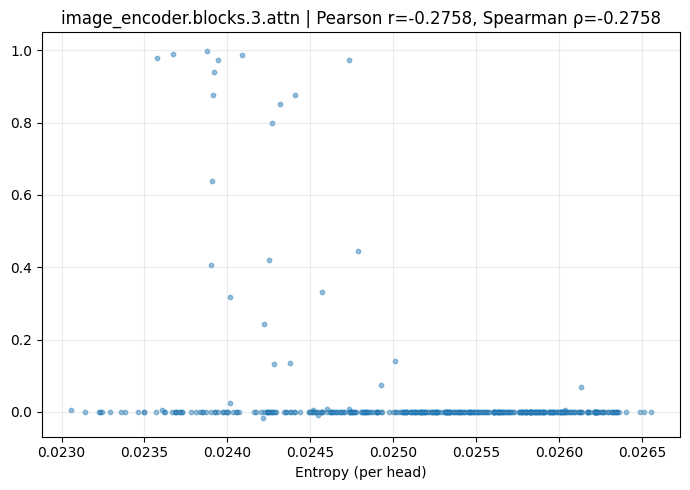

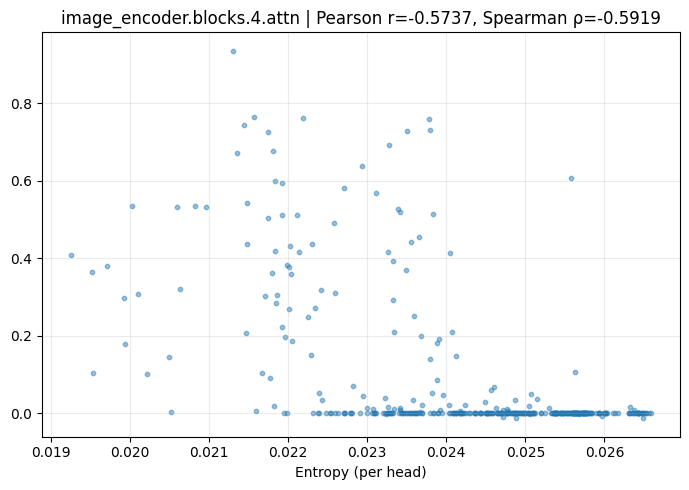

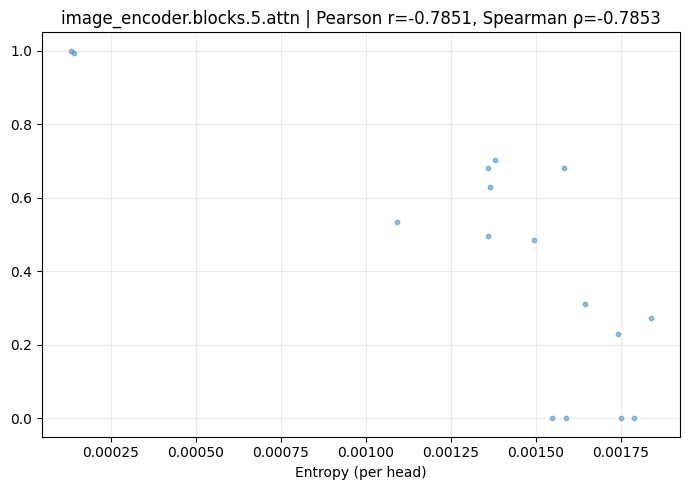

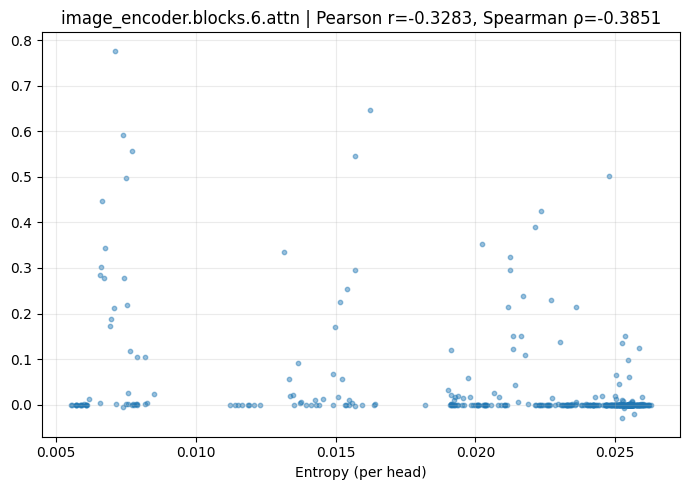

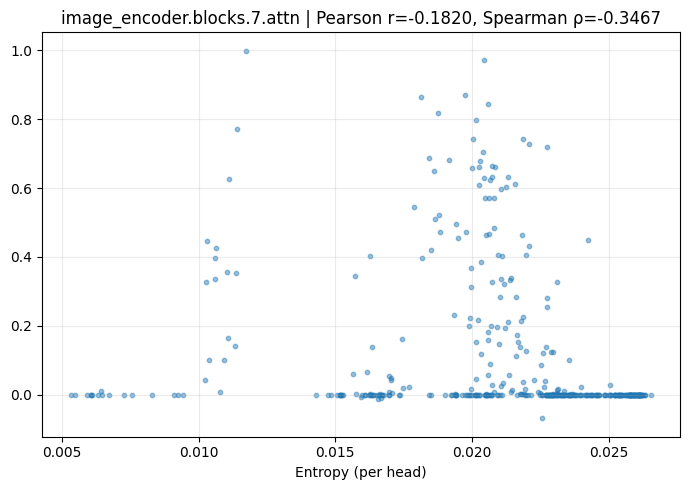

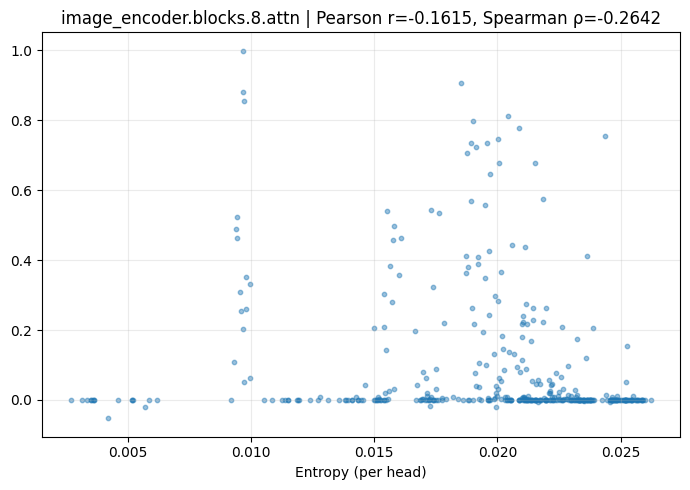

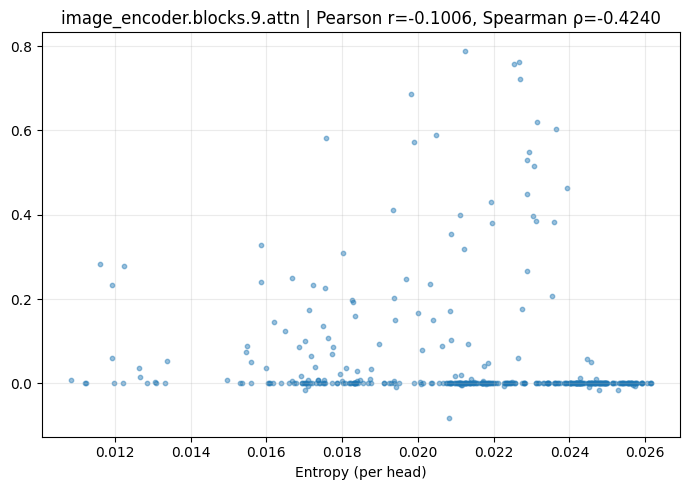

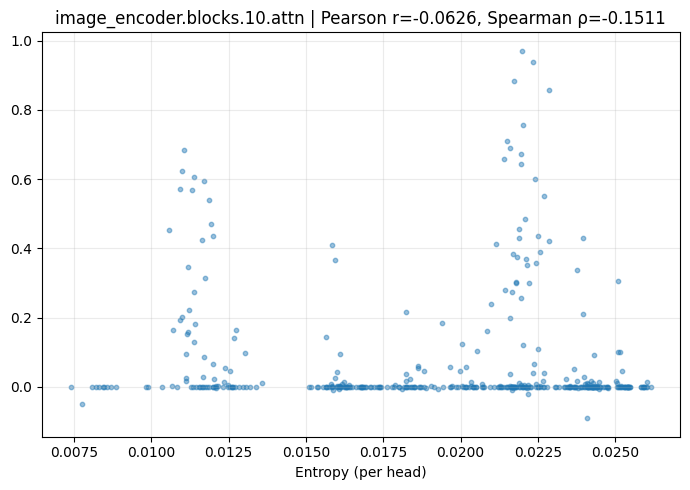

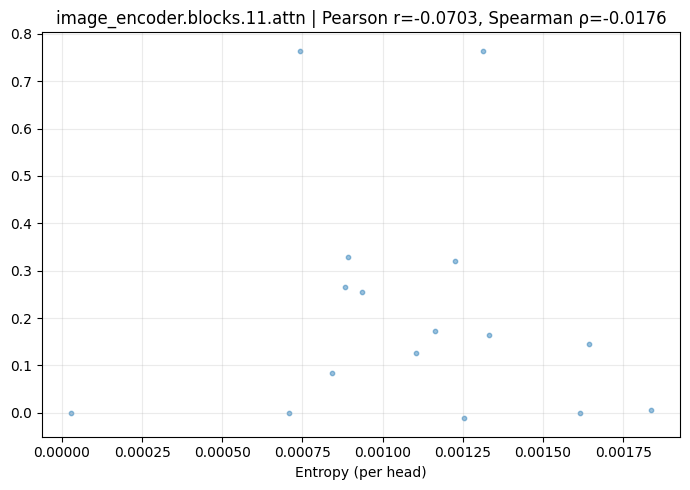

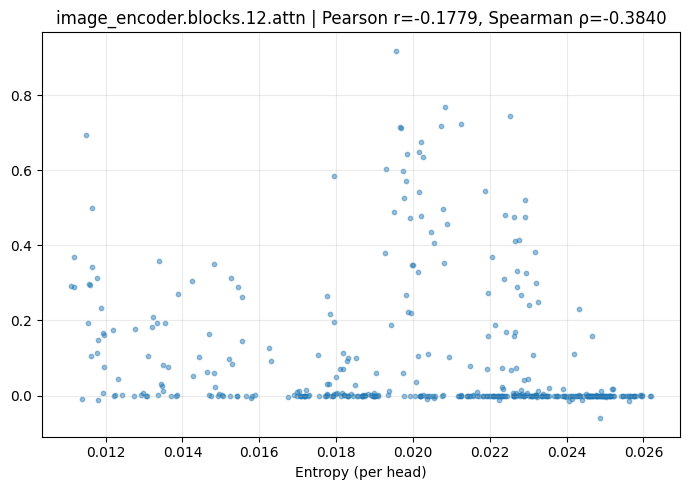

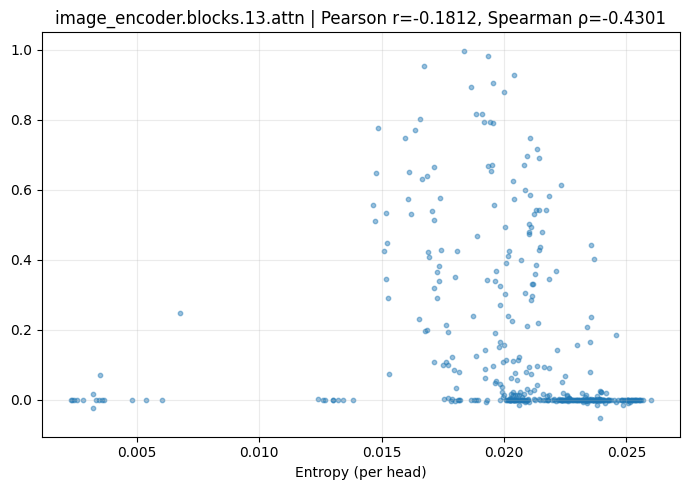

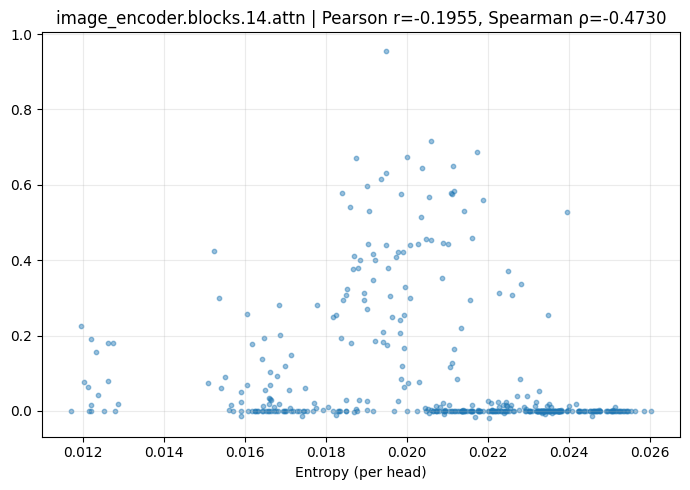

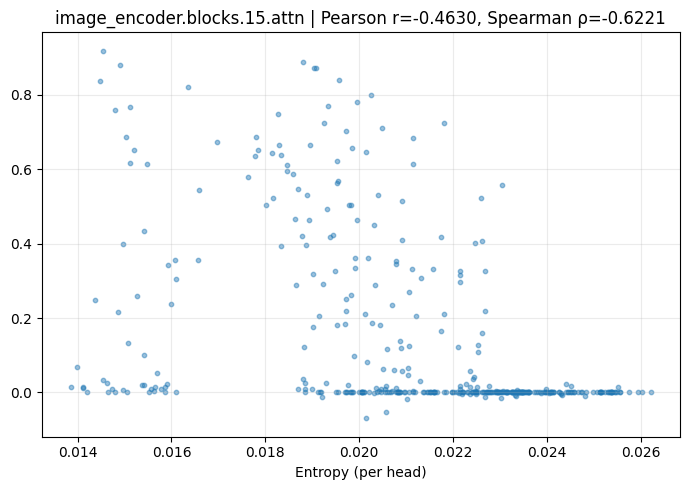

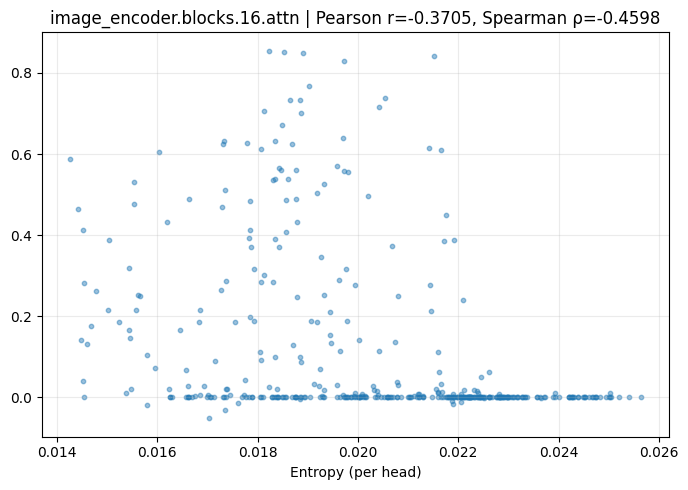

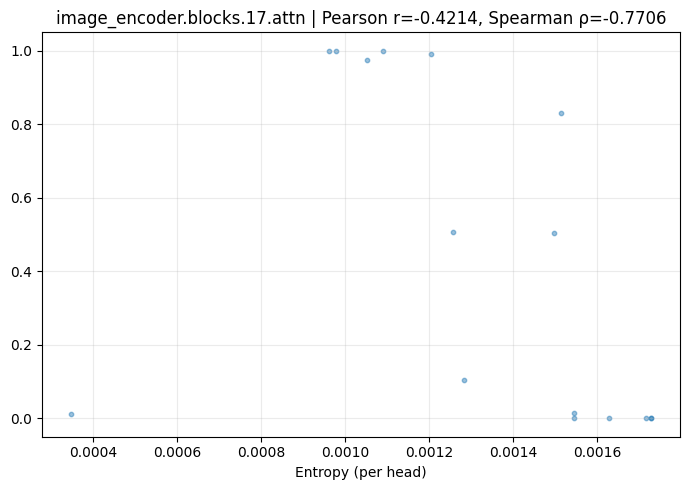

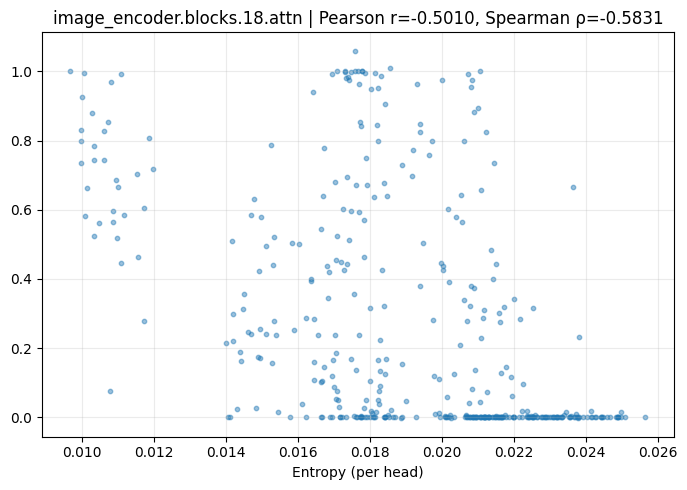

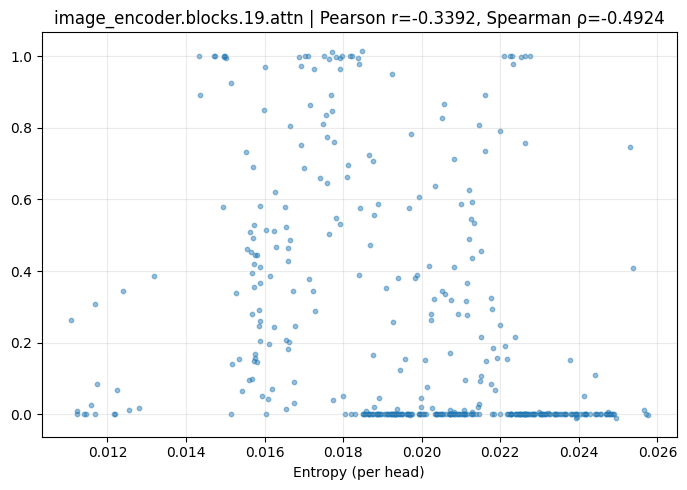

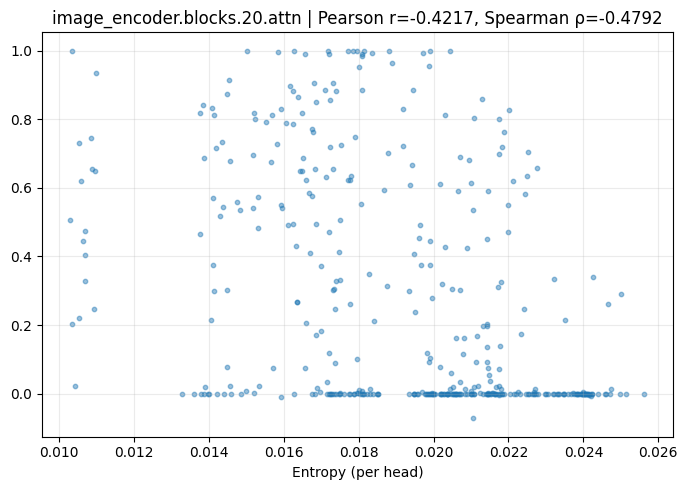

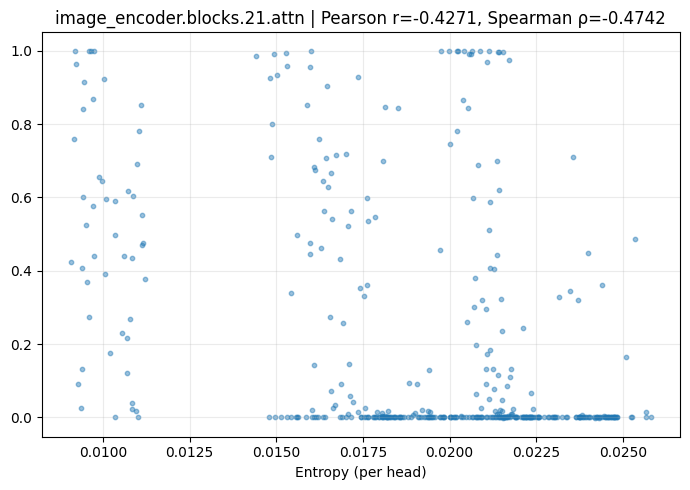

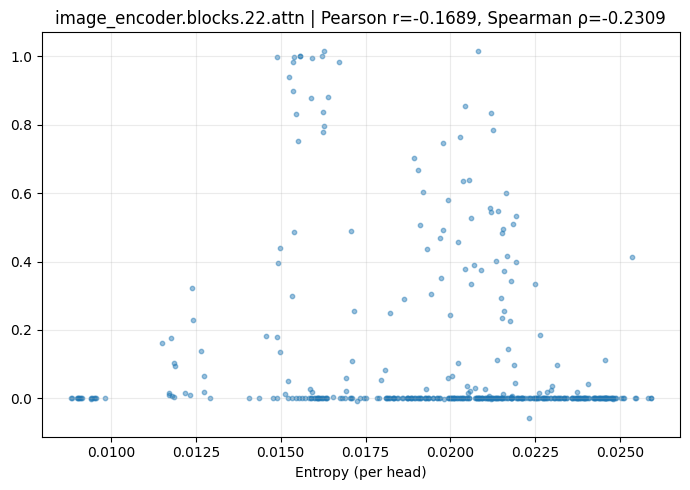

Global: N=8064 heads | Pearson r=-0.299584 | Spearman ρ=-0.453790

Top layers by |Pearson r|:
- image_encoder.blocks.5.attn: n=16, r=-0.785054, ρ=-0.785294
- image_encoder.blocks.2.attn: n=400, r=-0.714323, ρ=-0.393881
- image_encoder.blocks.0.attn: n=400, r=-0.673369, ρ=-0.171251
- image_encoder.blocks.4.attn: n=400, r=-0.573720, ρ=-0.591940
- image_encoder.blocks.18.attn: n=400, r=-0.501011, ρ=-0.583051
- image_encoder.blocks.15.attn: n=400, r=-0.463019, ρ=-0.622132
- image_encoder.blocks.21.attn: n=400, r=-0.427126, ρ=-0.474218
- image_encoder.blocks.20.attn: n=400, r=-0.421709, ρ=-0.479196
- image_encoder.blocks.17.attn: n=16, r=-0.421423, ρ=-0.770588
- image_encoder.blocks.16.attn: n=400, r=-0.370546, ρ=-0.459763


In [8]:


stats_splits_raw = plot_and_correlate_entropy_vs_gates_split(entropy_value, full_attention_heads,
    clamp_weights_0_1=False,
    per_layer_plots=True,
    max_layers_to_plot=23,
    title_prefix="(RAW) ")

stats_raw = plot_and_correlate_entropy_vs_gates(
    entropy_value, full_attention_heads,
    clamp_weights_0_1=False,
    per_layer_plots=True,
    max_layers_to_plot=23,
    title_prefix="(RAW) "
)

# stats_clamped = plot_and_correlate_entropy_vs_gates(
#     entropy_value, full_attention_heads,
#     clamp_weights_0_1=True,
#     clamp_method="sigmoid",   # or "minmax"
#     per_layer_plots=True,
#     max_layers_to_plot=23,
#     title_prefix="(CLAMPED) "
# )
